In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

### Loading the Iris Dataset:

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

### Fitting Gaussian Naive Bayes:

In [4]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Inspecting the Learned Gaussian Parameters:

Since Gaussian NB estimates a mean and variance per feature, per class, I can inspect exactly what it learned — this is the direct numeric equivalent of the "bell-shaped hills" described in the geometric intuition.

In [5]:
means = pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names)
variances = pd.DataFrame(gnb.var_, columns=iris.feature_names, index=iris.target_names)

print("Learned means (mu) per class:\n", means)
print("\nLearned variances (sigma^2) per class:\n", variances)

Learned means (mu) per class:
             sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                 5.0075            3.4150             1.4675   
versicolor             5.9300            2.7725             4.2500   
virginica              6.5450            2.9500             5.5200   

            petal width (cm)  
setosa                0.2350  
versicolor            1.3375  
virginica             2.0125  

Learned variances (sigma^2) per class:
             sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa               0.112694          0.135775           0.028194   
versicolor           0.272600          0.113494           0.236000   
virginica            0.382975          0.094000           0.274100   

            petal width (cm)  
setosa              0.009275  
versicolor          0.041844  
virginica           0.081094  


### Geometric Intuition — Visualizing the Decision Boundary:

Using just 2 features (petal length, petal width — the two most separating features in Iris) to plot the decision regions in 2D. Each class's region corresponds to wherever that class's Gaussian "hill" sits taller than the others.

Notice the boundaries are **curved**, not straight lines — a direct consequence of each class having a *different* variance per feature. If all classes shared identical variance, this boundary would collapse into straight lines, similar to Logistic Regression's linear boundary.

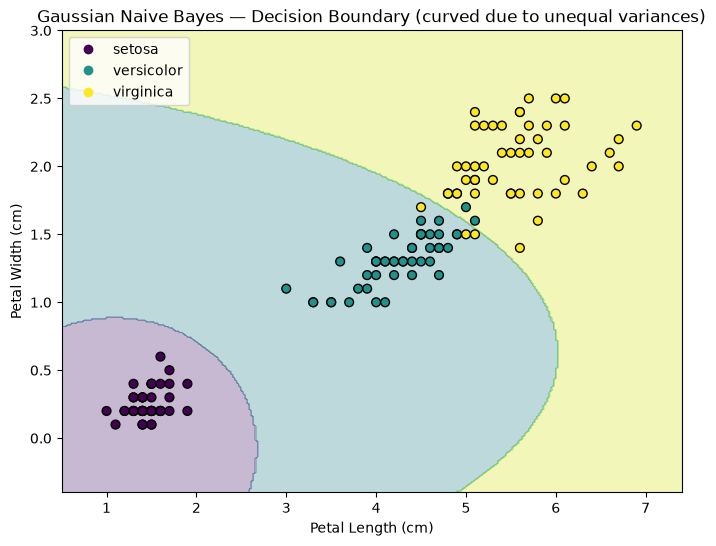

In [6]:
X_2d = X[:, 2:4]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=2, stratify=y)

gnb_2d = GaussianNB()
gnb_2d.fit(X_train_2d, y_train_2d)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Gaussian Naive Bayes — Decision Boundary (curved due to unequal variances)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

### Note: Feature Scaling Isn't Needed:

Unlike Logistic Regression, Gradient Descent-based models, or distance-based algorithms (KNN, SVM), Gaussian Naive Bayes doesn't require feature scaling. Since each feature's probability is estimated **independently** — no dot product or distance calculation ever compares magnitudes across features — differences in scale don't distort the model.

The cell below confirms this: fitting on raw features vs. standardized features gives (up to floating-point noise) the same accuracy.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print("Accuracy without scaling:", accuracy_score(y_test, y_pred))
print("Accuracy with scaling:   ", accuracy_score(y_test, y_pred_scaled))

Accuracy without scaling: 1.0
Accuracy with scaling:    1.0


### Summary:

- Gaussian NB models each class's feature distributions as independent normal curves.
- The decision boundary is curved whenever classes have unequal variance — no manual polynomial feature engineering needed to get non-linearity, unlike Logistic Regression.
- Feature scaling has no meaningful effect on the result, since each feature is evaluated independently of the others' scale.